In [2]:
import pandas as pd

In [3]:
data=pd.read_csv('train.csv')

In [4]:
data.head()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [5]:
data.shape

(4809, 23)

In [6]:


data.isnull().sum()

ID                          0
country                     0
age_group                   0
travel_with              1114
total_female                3
total_male                  5
purpose                     0
main_activity               0
info_source                 0
tour_arrangement            0
package_transport_int       0
package_accomodation        0
package_food                0
package_transport_tz        0
package_sightseeing         0
package_guided_tour         0
package_insurance           0
night_mainland              0
night_zanzibar              0
payment_mode                0
first_trip_tz               0
most_impressing           313
total_cost                  0
dtype: int64

In [7]:
for col in data.columns:
   
    print(data[col].isna().sum()/data.shape[0])

0.0
0.0
0.0
0.23164899147431897
0.0006238303181534623
0.001039717196922437
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.06508629652734456
0.0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   object 
 1   country                4809 non-null   object 
 2   age_group              4809 non-null   object 
 3   travel_with            3695 non-null   object 
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   object 
 7   main_activity          4809 non-null   object 
 8   info_source            4809 non-null   object 
 9   tour_arrangement       4809 non-null   object 
 10  package_transport_int  4809 non-null   object 
 11  package_accomodation   4809 non-null   object 
 12  package_food           4809 non-null   object 
 13  package_transport_tz   4809 non-null   object 
 14  package_sightseeing    4809 non-null   object 
 15  pack

In [ ]:
def create_features(df):
    """
    Feature Engineering SANS data leakage
    """
    df = df.copy()
    
    print("🔧 FEATURE ENGINEERING EN COURS...")
    
    # ===== NUMÉRIQUES (SANS UTILISER total_cost) =====
    print("1️⃣ Features numériques...")
    
    # Durées de séjour
    df['total_nights'] = df['night_mainland'] + df['night_zanzibar']
    
    # Taille du groupe
    df['group_size'] = df['total_female'] + df['total_male']
    
    # Ratios (SANS total_cost)
    df['ratio_zanzibar'] = df['night_zanzibar'] / (df['total_nights'] + 0.01)
    df['ratio_mainland'] = df['night_mainland'] / (df['total_nights'] + 0.01)
    df['gender_ratio'] = df['total_female'] / (df['total_male'] + 0.01)
    df['pct_female'] = df['total_female'] / (df['group_size'] + 0.01)
    df['pct_male'] = df['total_male'] / (df['group_size'] + 0.01)
    
    # Interactions numériques
    df['nights_x_group'] = df['total_nights'] * df['group_size']  # Capacité totale nuitées
    df['zanzibar_x_group'] = df['night_zanzibar'] * df['group_size']
    df['mainland_x_group'] = df['night_mainland'] * df['group_size']
    
    # Features quadratiques (capturer non-linéarité)
    df['group_size_squared'] = df['group_size'] ** 2
    df['total_nights_squared'] = df['total_nights'] ** 2
    
    # ===== CATÉGORIELLES =====
    print("2️⃣ Features catégorielles combinées...")
    
    # Package count (nombre de services inclus)
    package_cols = [col for col in df.columns if col.startswith('package_')]
    if package_cols:
        # Compter combien de packages = 'Yes'
        df['package_count'] = 0
        for col in package_cols:
            df['package_count'] += (df[col] == 'Yes').astype(int)
        
        df['full_package'] = (df['package_count'] >= 6).astype(int)  # Tous services inclus
        df['partial_package'] = ((df['package_count'] > 0) & (df['package_count'] < 6)).astype(int)
        df['no_package'] = (df['package_count'] == 0).astype(int)
    
    # Destination principale
    df['main_destination'] = (df['night_zanzibar'] > df['night_mainland']).astype(int)
    df['only_zanzibar'] = (df['night_zanzibar'] > 0) & (df['night_mainland'] == 0)
    df['only_mainland'] = (df['night_mainland'] > 0) & (df['night_zanzibar'] == 0)
    df['both_destinations'] = (df['night_zanzibar'] > 0) & (df['night_mainland'] > 0)
    
    # Profil voyageur (interactions catégorielles)
    if 'age_group' in df.columns and 'travel_with' in df.columns:
        df['traveler_profile'] = df['age_group'].astype(str) + '_' + df['travel_with'].astype(str)
    
    if 'purpose' in df.columns and 'age_group' in df.columns:
        df['purpose_age'] = df['purpose'].astype(str) + '_' + df['age_group'].astype(str)
    
    # Groupe familial ?
    if 'travel_with' in df.columns:
        df['is_family'] = df['travel_with'].str.contains('Family|Children', case=False, na=False).astype(int)
    
    # Premier voyage ?
    if 'first_trip_tz' in df.columns:
        df['first_trip_binary'] = (df['first_trip_tz'] == 'Yes').astype(int)
    
    print(f"✅ Features créées : {df.shape[1]} colonnes")
    
    return df

# APPLICATION
data= create_features(data)

🔧 FEATURE ENGINEERING EN COURS...
1️⃣ Features numériques...
2️⃣ Features catégorielles combinées...
✅ Features créées : 47 colonnes


In [10]:
cat_data=[]
num_data=[]
for i,c in enumerate(data.dtypes):
    if c=='O':
        cat_data.append(data.iloc[:,i])
    else:
        num_data.append(data.iloc[:,i])

cat_data=pd.DataFrame(cat_data).transpose()
num_data=pd.DataFrame(num_data).transpose()

In [11]:

cat_data

,ID,country,age_group,travel_with,purpose,main_activity,info_source,tour_arrangement,package_transport_int,package_accomodation,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,payment_mode,first_trip_tz,most_impressing,traveler_profile,purpose_age
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,Cash,No,Friendly People,45-64_Friends/Relatives,Leisure and Holidays_45-64
1,tour_10,UNITED KINGDOM,25-44,NaN,Leisure and Holidays,Cultural tourism,others,Independent,No,No,No,No,No,No,No,Cash,Yes,"Wonderful Country, Landscape, Nature",25-44_nan,Leisure and Holidays_25-44
2,tour_1000,UNITED KINGDOM,25-44,Alone,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,Cash,No,Excellent Experience,25-44_Alone,Visiting Friends and Relatives_25-44
3,tour_1002,UNITED KINGDOM,25-44,Spouse,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,No,Yes,Yes,Yes,Yes,Yes,No,Cash,Yes,Friendly People,25-44_Spouse,Leisure and Holidays_25-44
4,tour_1004,CHINA,1-24,NaN,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,No,No,No,No,No,No,No,Cash,Yes,No comments,1-24_nan,Leisure and Holidays_1-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,tour_993,UAE,45-64,Alone,Business,Hunting tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,Credit Card,No,No comments,45-64_Alone,Business_45-64
4805,tour_994,UNITED STATES OF AMERICA,25-44,Spouse,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Cash,Yes,Friendly People,25-44_Spouse,Leisure and Holidays_25-44
4806,tour_995,NETHERLANDS,1-24,NaN,Leisure and Holidays,Wildlife tourism,others,Independent,No,No,No,No,No,No,No,Cash,Yes,Good service,1-24_nan,Leisure and Holidays_1-24
4807,tour_997,SOUTH AFRICA,25-44,Friends/Relatives,Business,Beach tourism,"Travel, agent, tour operator",Independent,Yes,Yes,Yes,No,No,No,No,Credit Card,No,Friendly People,25-44_Friends/Relatives,Business_25-44


In [12]:
cat_data.isna().sum()

ID                          0
country                     0
age_group                   0
travel_with              1114
purpose                     0
main_activity               0
info_source                 0
tour_arrangement            0
package_transport_int       0
package_accomodation        0
package_food                0
package_transport_tz        0
package_sightseeing         0
package_guided_tour         0
package_insurance           0
payment_mode                0
first_trip_tz               0
most_impressing           313
traveler_profile            0
purpose_age                 0
dtype: int64

In [13]:
cat_data.describe()

,ID,country,age_group,travel_with,purpose,main_activity,info_source,tour_arrangement,package_transport_int,package_accomodation,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,payment_mode,first_trip_tz,most_impressing,traveler_profile,purpose_age
count,4809,4809,4809,3695,4809,4809,4809,4809,4809,4809,4809,4809,4809,4809,4809,4809,4809,4496,4809,4809
unique,4809,105,4,5,7,9,8,2,2,2,2,2,2,2,2,4,2,7,24,28
top,tour_999,UNITED STATES OF AMERICA,25-44,Alone,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,No,No,No,No,No,No,No,Cash,Yes,Friendly People,25-44_Alone,Leisure and Holidays_25-44
freq,1,695,2487,1265,2840,2259,1913,2570,3357,2602,2748,2919,3319,3259,4079,4172,3243,1541,697,1324


In [14]:
cat_data=cat_data.apply(lambda x: x.fillna(x.value_counts().index[0]))
cat_data.isna().sum()

ID                       0
country                  0
age_group                0
travel_with              0
purpose                  0
main_activity            0
info_source              0
tour_arrangement         0
package_transport_int    0
package_accomodation     0
package_food             0
package_transport_tz     0
package_sightseeing      0
package_guided_tour      0
package_insurance        0
payment_mode             0
first_trip_tz            0
most_impressing          0
traveler_profile         0
purpose_age              0
dtype: int64

In [15]:
for col in cat_data.columns:
    print(f"\n{col}")
    print(cat_data[col].value_counts())
    print(f"→ Cardinalité : {cat_data[col].nunique()} modalités")


ID
ID
tour_999     1
tour_0       1
tour_10      1
tour_1000    1
tour_1002    1
            ..
tour_1017    1
tour_1016    1
tour_1013    1
tour_1012    1
tour_1011    1
Name: count, Length: 4809, dtype: int64
→ Cardinalité : 4809 modalités

country
country
UNITED STATES OF AMERICA    695
UNITED KINGDOM              533
ITALY                       393
FRANCE                      280
ZIMBABWE                    274
                           ... 
CYPRUS                        1
URUGUAY                       1
MORROCO                       1
BERMUDA                       1
ESTONIA                       1
Name: count, Length: 105, dtype: int64
→ Cardinalité : 105 modalités

age_group
age_group
25-44    2487
45-64    1391
1-24      624
65+       307
Name: count, dtype: int64
→ Cardinalité : 4 modalités

travel_with
travel_with
Alone                  2379
Spouse                 1005
Friends/Relatives       895
Spouse and Children     368
Children                162
Name: count, dtype: int

In [16]:
# 1. SUPPRIMER ID
cat_data = cat_data.drop('ID', axis=1)

# 2. SÉPARER SELON CARDINALITÉ
low_card = [col for col in cat_data.columns if cat_data[col].nunique() <= 10]
high_card = [col for col in cat_data.columns if cat_data[col].nunique() > 10]

# 3. ONE-HOT ENCODING (faible cardinalité)
from sklearn.preprocessing import OneHotEncoder
#encoder = OneHotEncoder(drop='first', sparse_output=False)
#cat_encoded_low = encoder.fit_transform(cat_data[low_card])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_encoded_low = encoder.fit_transform(cat_data[low_card])

# 4. FREQUENCY ENCODING (haute cardinalité)
cat_encoded_high = cat_data[high_card].copy()
for col in high_card:
    freq = cat_data[col].value_counts(normalize=True)
    cat_encoded_high[col] = cat_data[col].map(freq)

# 5. COMBINER
import pandas as pd
cat_final = pd.concat([
    pd.DataFrame(cat_encoded_low, columns=encoder.get_feature_names_out()),
    cat_encoded_high
], axis=1)

In [17]:
cat_final

,age_group_1-24,age_group_25-44,age_group_45-64,age_group_65+,travel_with_Alone,travel_with_Children,travel_with_Friends/Relatives,travel_with_Spouse,travel_with_Spouse and Children,purpose_Business,...,most_impressing_ Wildlife,most_impressing_Excellent Experience,most_impressing_Friendly People,most_impressing_Good service,most_impressing_No comments,most_impressing_Satisfies and Hope Come Back,"most_impressing_Wonderful Country, Landscape, Nature",country,traveler_profile,purpose_age
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.013308,0.041589,0.190268
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.110834,0.127469,0.275317
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.110834,0.144937,0.070285
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.110834,0.101268,0.275317
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.013516,0.037222,0.072572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.006862,0.057184,0.030360
4805,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.144521,0.101268,0.275317
4806,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.023290,0.037222,0.072572
4807,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.048867,0.103764,0.098565



je suis la

In [18]:
num_data

,total_female,total_male,night_mainland,night_zanzibar,total_cost,total_nights,group_size,ratio_zanzibar,ratio_mainland,gender_ratio,...,package_count,full_package,partial_package,no_package,main_destination,only_zanzibar,only_mainland,both_destinations,is_family,first_trip_binary
0,1.0,1.0,13.0,0.0,674602.5,13.0,2.0,0.000000,0.999231,0.990099,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,14.0,7.0,3214906.5,21.0,1.0,0.333175,0.666349,100.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.0,1.0,1.0,31.0,3315000.0,32.0,1.0,0.968447,0.031240,0.000000,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,1.0,11.0,0.0,7790250.0,11.0,2.0,0.000000,0.999092,0.990099,...,5.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,7.0,4.0,1657500.0,11.0,1.0,0.363306,0.635786,100.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,0.0,1.0,2.0,0.0,3315000.0,2.0,1.0,0.000000,0.995025,0.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4805,1.0,1.0,11.0,0.0,10690875.0,11.0,2.0,0.000000,0.999092,0.990099,...,7.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4806,1.0,0.0,3.0,7.0,2246636.7,10.0,1.0,0.699301,0.299700,100.000000,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
4807,1.0,1.0,5.0,0.0,1160250.0,5.0,2.0,0.000000,0.998004,0.990099,...,3.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
num_data.describe()

,total_female,total_male,night_mainland,night_zanzibar,total_cost,total_nights,group_size,ratio_zanzibar,ratio_mainland,gender_ratio,...,package_count,full_package,partial_package,no_package,main_destination,only_zanzibar,only_mainland,both_destinations,is_family,first_trip_binary
count,4806.000000,4804.000000,4809.000000,4809.000000,4.809000e+03,4809.000000,4801.000000,4809.000000,4809.000000,4801.000000,...,4809.000000,4809.000000,4809.000000,4809.000000,4809.000000,4809.000000,4809.000000,4809.000000,4809.000000,4809.000000
mean,0.926758,1.009575,8.488043,2.304429,8.114389e+06,10.792472,1.932306,0.207438,0.788353,29.448947,...,2.366396,0.177376,0.293408,0.529216,0.152838,0.109378,0.626326,0.262009,0.110210,0.674361
std,1.288242,1.138865,10.427624,4.227080,1.222490e+07,10.779025,2.073996,0.334368,0.335939,61.457989,...,2.674695,0.382026,0.455371,0.499198,0.359869,0.312146,0.483829,0.439773,0.313184,0.468662
min,0.000000,0.000000,0.000000,0.000000,4.900000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,3.000000,0.000000,8.121750e+05,4.000000,1.000000,0.000000,0.665927,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,6.000000,0.000000,3.397875e+06,8.000000,2.000000,0.000000,0.996678,0.990099,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,1.000000,11.000000,4.000000,9.945000e+06,14.000000,2.000000,0.333111,0.998573,2.970297,...,5.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,49.000000,44.000000,145.000000,61.000000,9.953288e+07,145.000000,93.000000,0.999836,0.999931,1100.000000,...,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


📊 ANALYSE DISTRIBUTION VARIABLES NUMÉRIQUES

            Variable      Moyenne      Médiane          Std     Min          Max  Skewness           Interprétation
        total_female 9.267582e-01 1.000000e+00 1.288242e+00     0.0 4.900000e+01 13.032958 ⚠️ Fortement asymétrique
          total_male 1.009575e+00 1.000000e+00 1.138865e+00     0.0 4.400000e+01 13.805829 ⚠️ Fortement asymétrique
      night_mainland 8.488043e+00 6.000000e+00 1.042762e+01     0.0 1.450000e+02  4.024788 ⚠️ Fortement asymétrique
      night_zanzibar 2.304429e+00 0.000000e+00 4.227080e+00     0.0 6.100000e+01  4.225400 ⚠️ Fortement asymétrique
          total_cost 8.114389e+06 3.397875e+06 1.222490e+07 49000.0 9.953288e+07  2.966922 ⚠️ Fortement asymétrique
        total_nights 1.079247e+01 8.000000e+00 1.077902e+01     0.0 1.450000e+02  3.691016 ⚠️ Fortement asymétrique
          group_size 1.932306e+00 2.000000e+00 2.073996e+00     0.0 9.300000e+01 19.974005 ⚠️ Fortement asymétrique
      ratio_zanzibar 2.0743

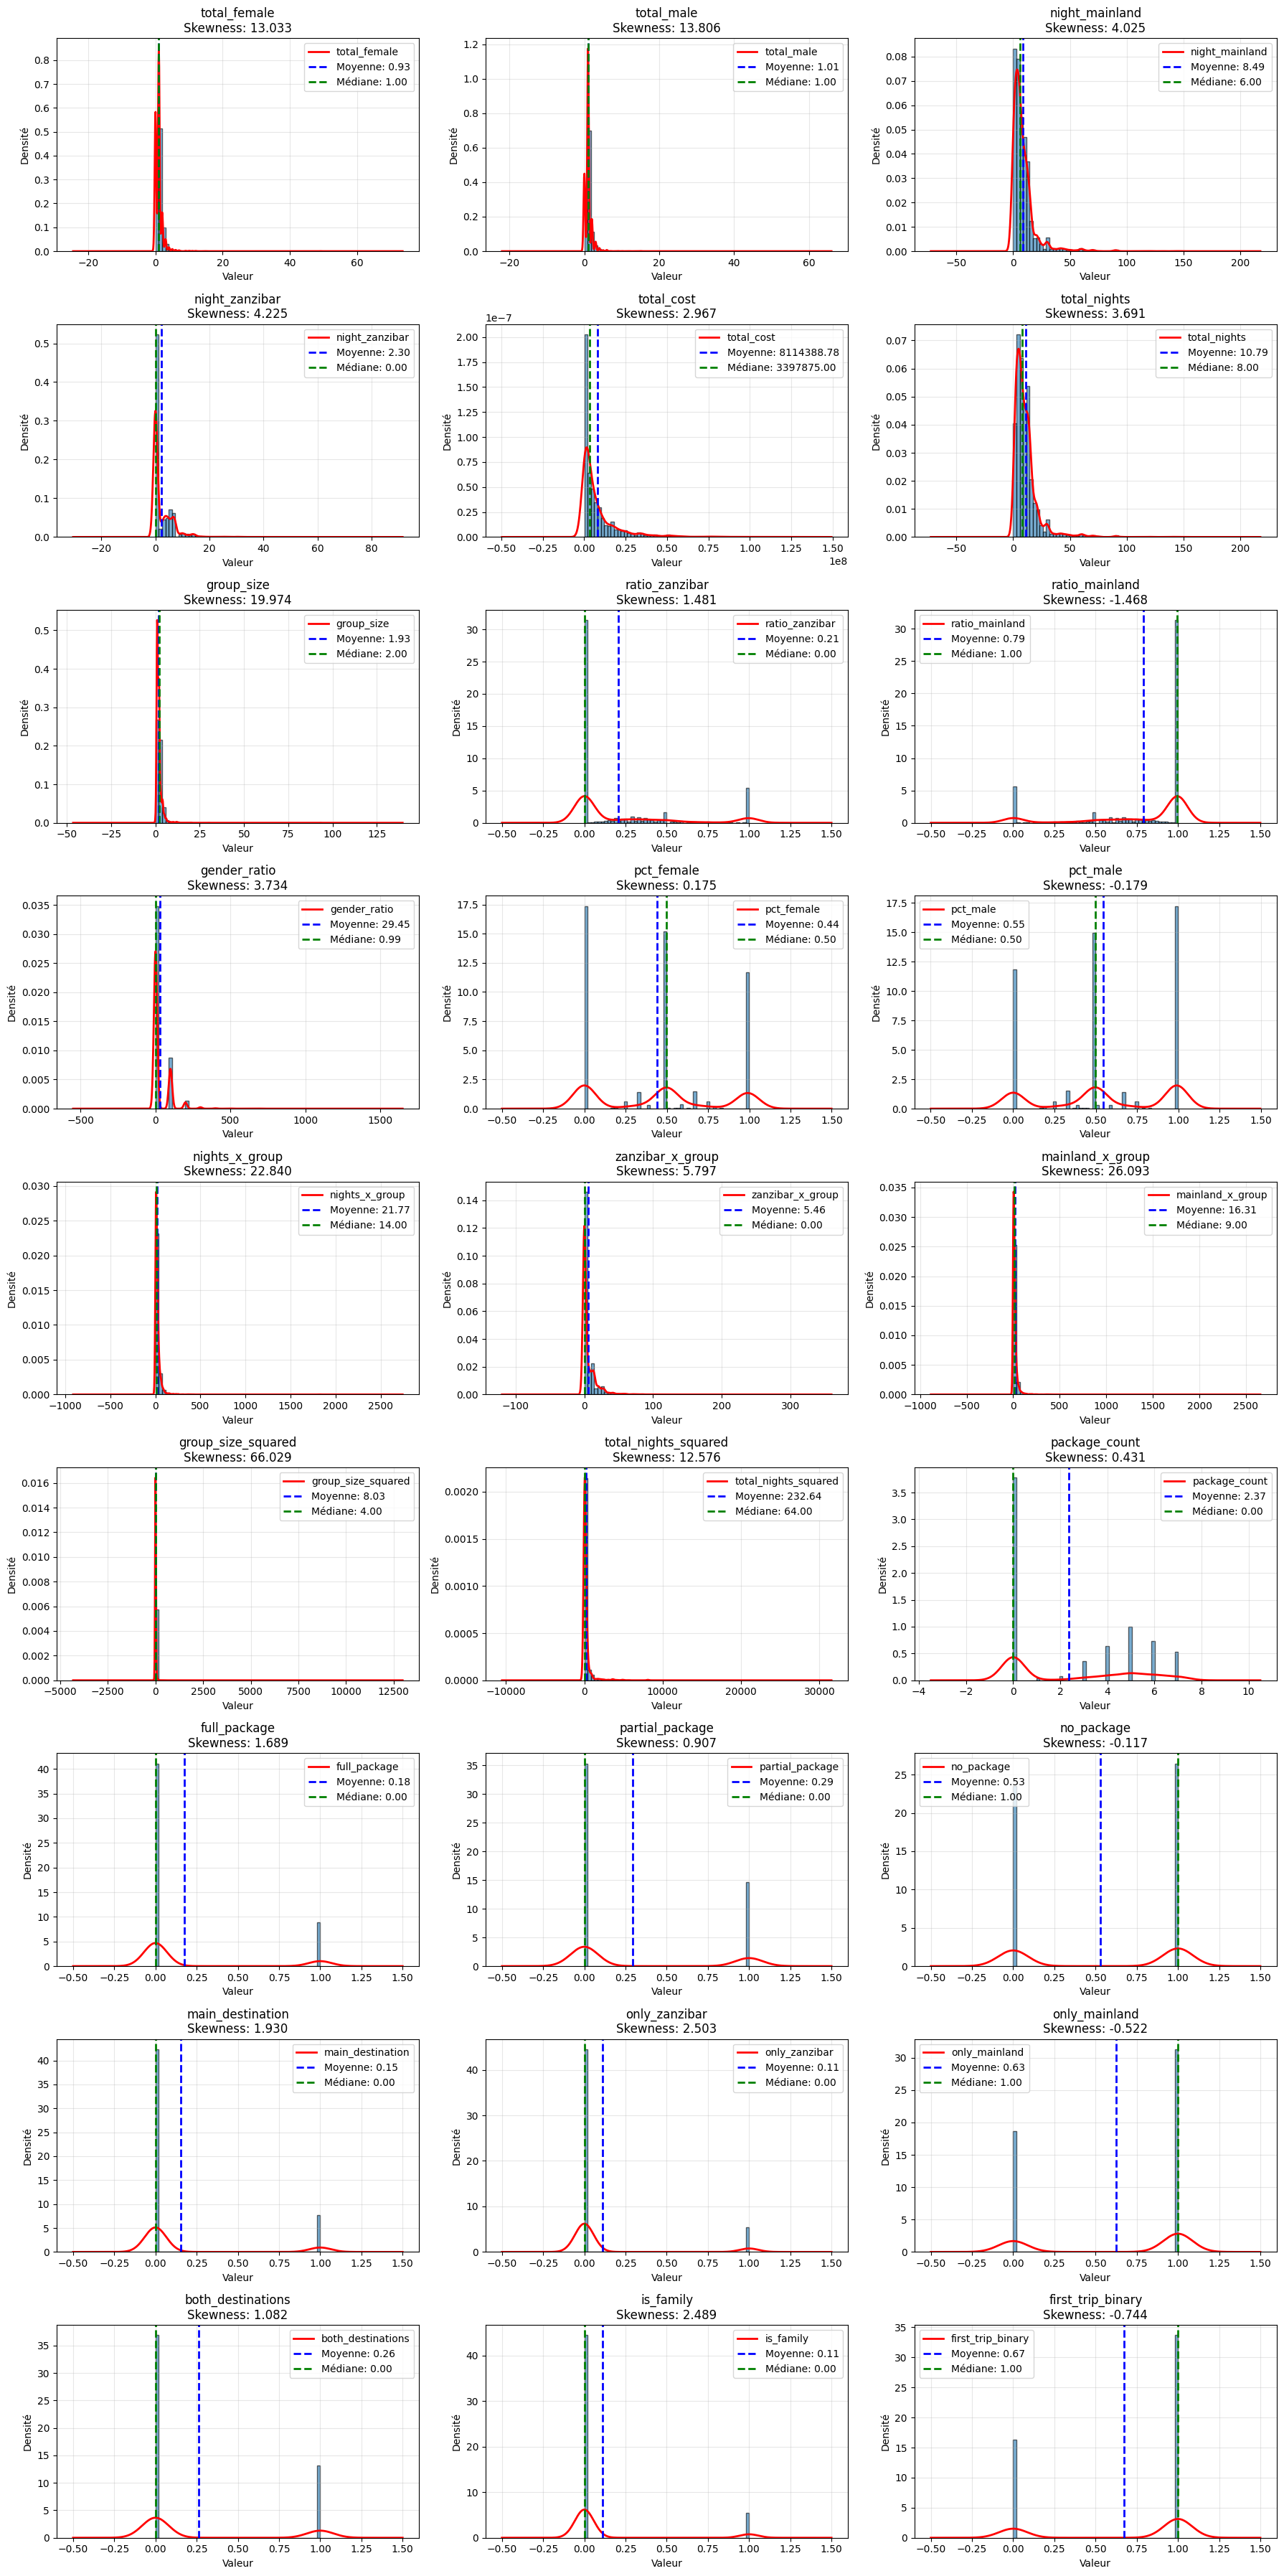


💡 RECOMMANDATIONS TRANSFORMATION :

⚠️ total_female
   Skewness : 13.033
   → TRANSFORMATION LOG recommandée

⚠️ total_male
   Skewness : 13.806
   → TRANSFORMATION LOG recommandée

⚠️ night_mainland
   Skewness : 4.025
   → TRANSFORMATION LOG recommandée

⚠️ night_zanzibar
   Skewness : 4.225
   → TRANSFORMATION LOG recommandée

⚠️ total_cost
   Skewness : 2.967
   → TRANSFORMATION LOG recommandée

⚠️ total_nights
   Skewness : 3.691
   → TRANSFORMATION LOG recommandée

⚠️ group_size
   Skewness : 19.974
   → TRANSFORMATION LOG recommandée

⚠️ ratio_zanzibar
   Skewness : 1.481
   → TRANSFORMATION LOG recommandée

⚠️ ratio_mainland
   Skewness : -1.468
   → TRANSFORMATION LOG recommandée

⚠️ gender_ratio
   Skewness : 3.734
   → TRANSFORMATION LOG recommandée

⚠️ nights_x_group
   Skewness : 22.840
   → TRANSFORMATION LOG recommandée

⚠️ zanzibar_x_group
   Skewness : 5.797
   → TRANSFORMATION LOG recommandée

⚠️ mainland_x_group
   Skewness : 26.093
   → TRANSFORMATION LOG recommand

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

def analyze_numerical_distribution(df):
    """
    Analyse complète de la distribution des variables numériques
    """
    # Sélectionner colonnes numériques
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    
    print("="*80)
    print("📊 ANALYSE DISTRIBUTION VARIABLES NUMÉRIQUES")
    print("="*80)
    
    # Tableau récapitulatif
    distribution_summary = []
    
    for col in num_cols:
        skewness = skew(df[col].dropna())
        
        summary = {
            'Variable': col,
            'Moyenne': df[col].mean(),
            'Médiane': df[col].median(),
            'Std': df[col].std(),
            'Min': df[col].min(),
            'Max': df[col].max(),
            'Skewness': skewness,
            'Interprétation': ''
        }
        
        # Interprétation skewness
        if abs(skewness) < 0.5:
            summary['Interprétation'] = '✅ Symétrique'
        elif abs(skewness) < 1:
            summary['Interprétation'] = '🟡 Modérément asymétrique'
        else:
            summary['Interprétation'] = '⚠️ Fortement asymétrique'
        
        distribution_summary.append(summary)
    
    # Afficher tableau
    df_summary = pd.DataFrame(distribution_summary)
    print("\n" + df_summary.to_string(index=False))
    
    # Visualisations
    n_cols_plot = len(num_cols)
    n_rows = (n_cols_plot + 2) // 3  # 3 colonnes par ligne
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4))
    axes = axes.flatten() if n_cols_plot > 1 else [axes]
    
    for idx, col in enumerate(num_cols):
        # Histogramme + KDE
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.6, density=True)
        df[col].dropna().plot(kind='kde', ax=axes[idx], color='red', linewidth=2)
        axes[idx].axvline(df[col].mean(), color='blue', linestyle='--', linewidth=2, label=f'Moyenne: {df[col].mean():.2f}')
        axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Médiane: {df[col].median():.2f}')
        axes[idx].set_title(f'{col}\nSkewness: {skew(df[col].dropna()):.3f}')
        axes[idx].set_xlabel('Valeur')
        axes[idx].set_ylabel('Densité')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)
    
    # Masquer axes vides
    for idx in range(len(num_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Recommandations
    print("\n" + "="*80)
    print("💡 RECOMMANDATIONS TRANSFORMATION :")
    print("="*80)
    
    for summary in distribution_summary:
        if abs(summary['Skewness']) > 1:
            print(f"\n⚠️ {summary['Variable']}")
            print(f"   Skewness : {summary['Skewness']:.3f}")
            print(f"   → TRANSFORMATION LOG recommandée")
        elif abs(summary['Skewness']) > 0.5:
            print(f"\n🟡 {summary['Variable']}")
            print(f"   Skewness : {summary['Skewness']:.3f}")
            print(f"   → Tester avec et sans transformation")
    
    return df_summary

# UTILISATION
distribution_analysis = analyze_numerical_distribution(num_data)


🔍 DÉTECTION OUTLIERS (MÉTHODE IQR)

            Variable            Q1           Q3          IQR     Borne_inf    Borne_sup  Nb_outliers  Pct_outliers                     Action
        total_female      0.000000 1.000000e+00 1.000000e+00 -1.500000e+00 2.500000e+00          256      5.323352 ⚠️ Modèles robustes (> 5%)
          total_male      1.000000 1.000000e+00 0.000000e+00  1.000000e+00 1.000000e+00         1843     38.323976 ⚠️ Modèles robustes (> 5%)
      night_mainland      3.000000 1.100000e+01 8.000000e+00 -9.000000e+00 2.300000e+01          274      5.697650 ⚠️ Modèles robustes (> 5%)
      night_zanzibar      0.000000 4.000000e+00 4.000000e+00 -6.000000e+00 1.000000e+01          186      3.867748          🟡 Analyser (1-5%)
          total_cost 812175.000000 9.945000e+06 9.132825e+06 -1.288706e+07 2.364424e+07          424      8.816802 ⚠️ Modèles robustes (> 5%)
        total_nights      4.000000 1.400000e+01 1.000000e+01 -1.100000e+01 2.900000e+01          247      5.1362

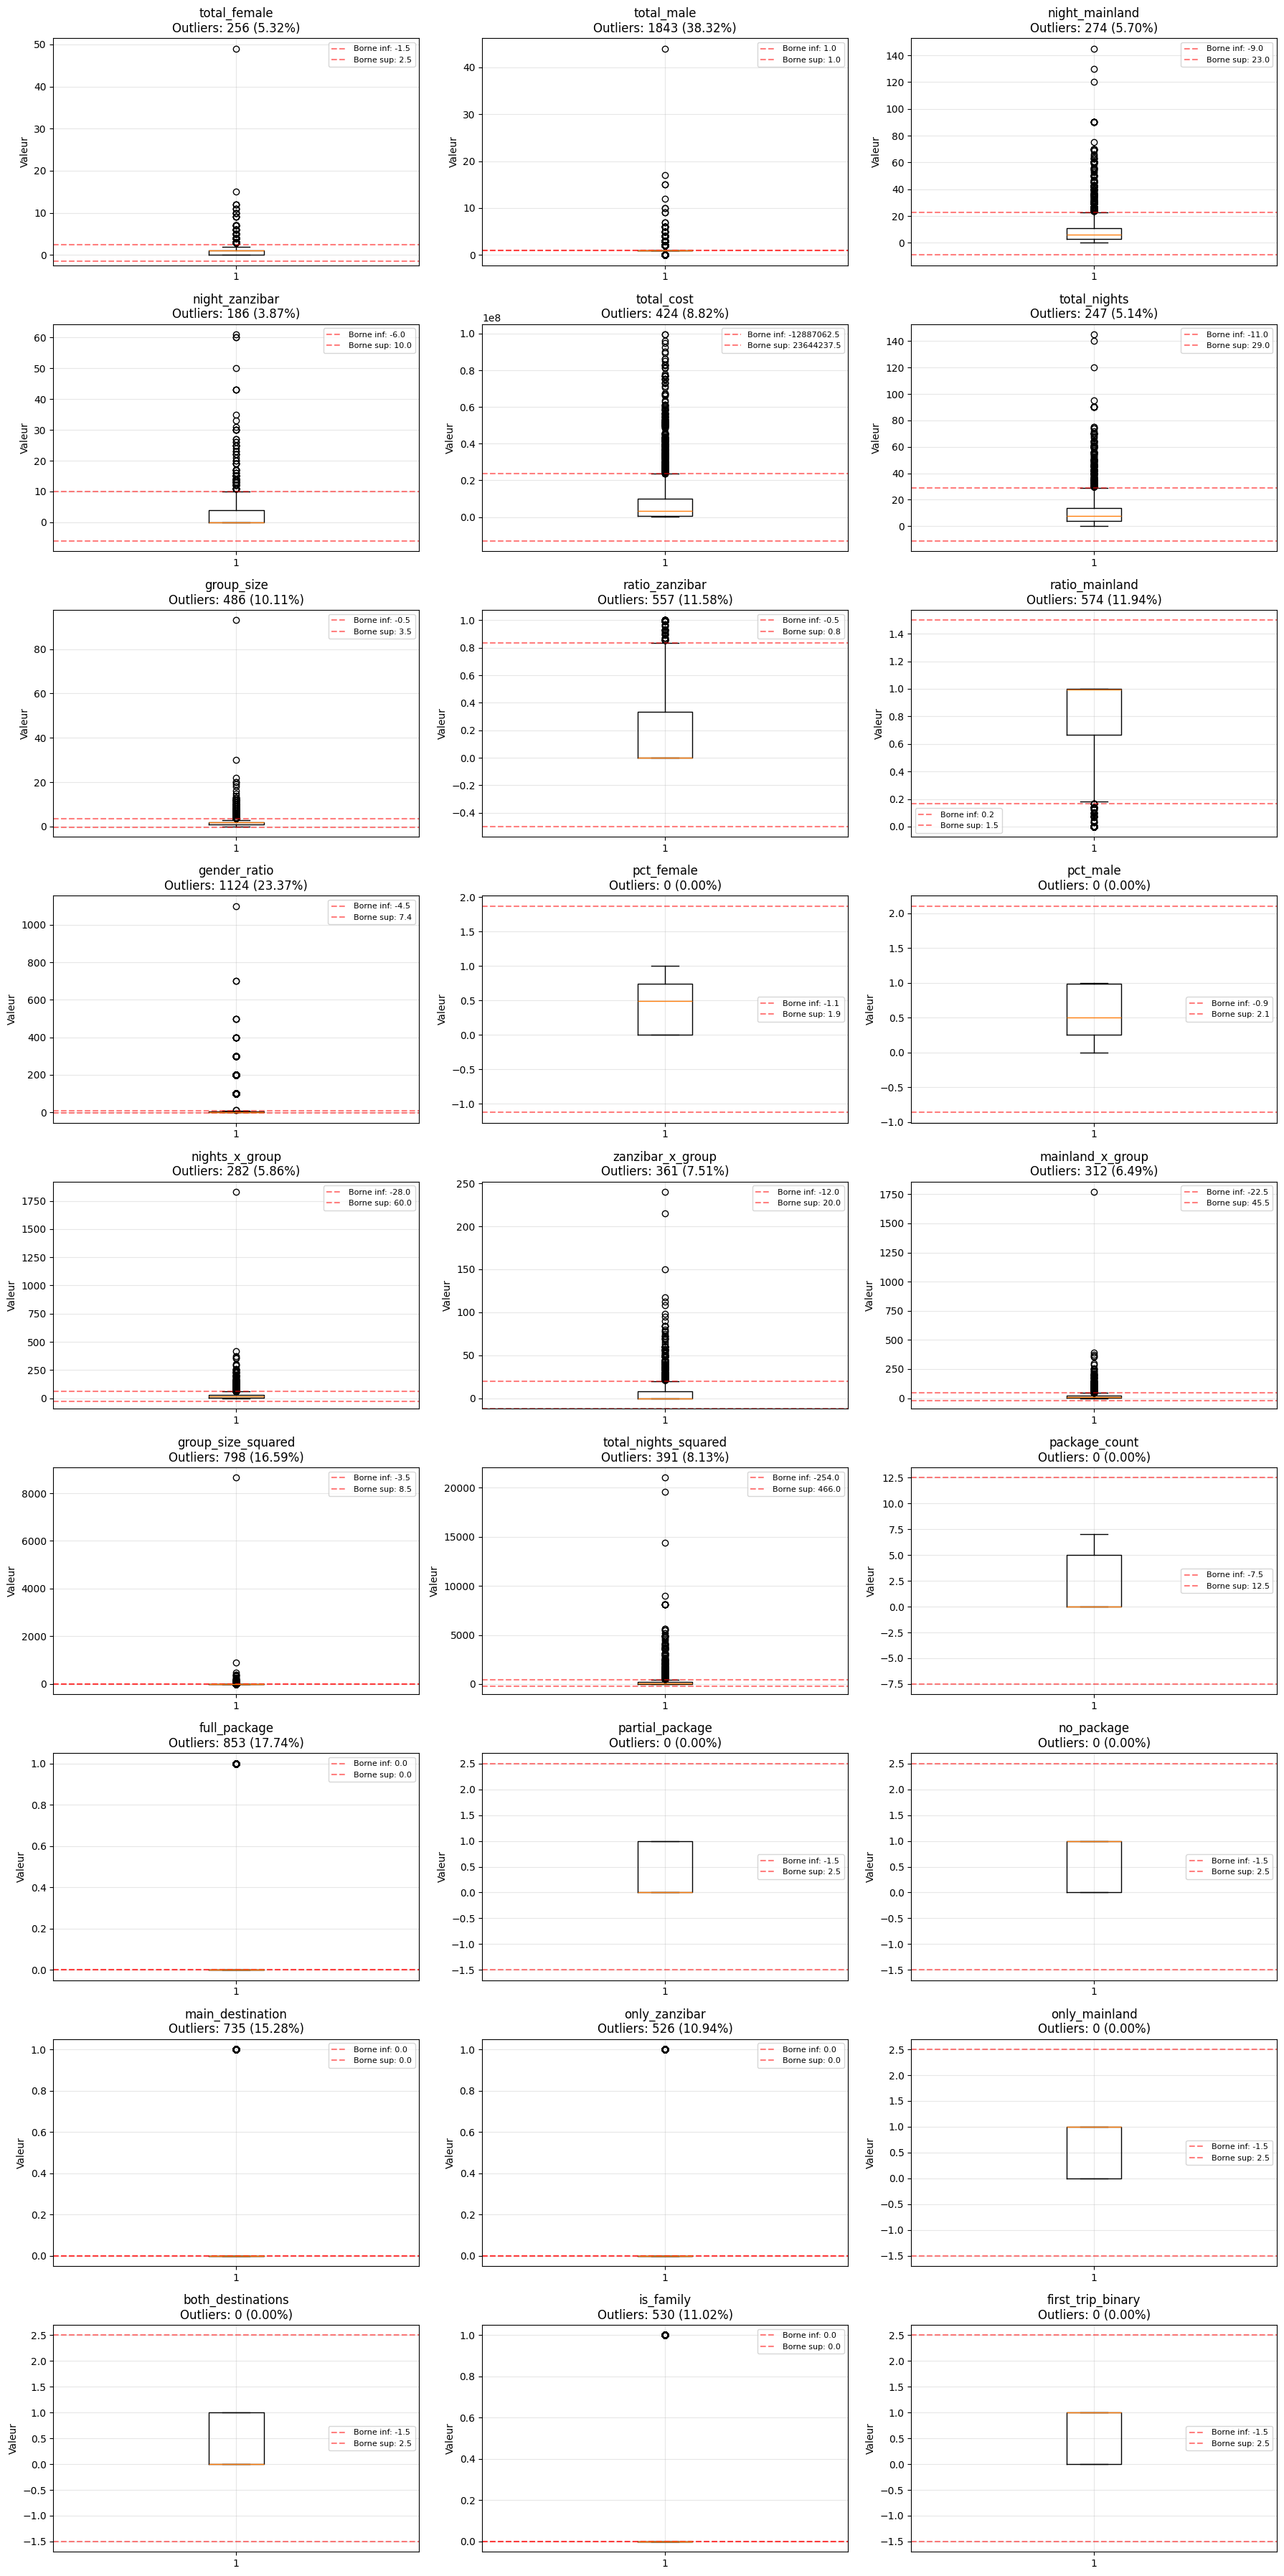


📋 DÉTAILS OUTLIERS PAR VARIABLE :

Variable : total_female
Outliers : 256 (5.32%)
Bornes   : [-1.50, 2.50]
Exemples : [4. 3. 4. 5. 3.]
Action   : ⚠️ Modèles robustes (> 5%)

Variable : total_male
Outliers : 1843 (38.32%)
Bornes   : [1.00, 1.00]
Exemples : [0. 0. 0. 0. 2.]
Action   : ⚠️ Modèles robustes (> 5%)

Variable : night_mainland
Outliers : 274 (5.70%)
Bornes   : [-9.00, 23.00]
Exemples : [30. 24. 70. 24. 56.]
Action   : ⚠️ Modèles robustes (> 5%)

Variable : night_zanzibar
Outliers : 186 (3.87%)
Bornes   : [-6.00, 10.00]
Exemples : [31. 11. 30. 13. 15.]
Action   : 🟡 Analyser (1-5%)

Variable : total_cost
Outliers : 424 (8.82%)
Bornes   : [-12887062.50, 23644237.50]
Exemples : [25442625. 28450500. 34039950. 33150000. 50553750.]
Action   : ⚠️ Modèles robustes (> 5%)

Variable : total_nights
Outliers : 247 (5.14%)
Bornes   : [-11.00, 29.00]
Exemples : [32. 30. 70. 56. 38.]
Action   : ⚠️ Modèles robustes (> 5%)

Variable : group_size
Outliers : 486 (10.11%)
Bornes   : [-0.50, 3.50]

In [21]:
def detect_outliers_iqr(df):
    """
    Détecte outliers avec méthode IQR pour toutes variables numériques
    """
    # Sélectionner colonnes numériques
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    
    print("="*80)
    print("🔍 DÉTECTION OUTLIERS (MÉTHODE IQR)")
    print("="*80)
    
    outliers_summary = []
    
    for col in num_cols:
        # Calculer IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Bornes
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Détecter outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        n_outliers = len(outliers)
        pct_outliers = (n_outliers / len(df)) * 100
        
        summary = {
            'Variable': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Borne_inf': lower_bound,
            'Borne_sup': upper_bound,
            'Nb_outliers': n_outliers,
            'Pct_outliers': pct_outliers,
            'Action': ''
        }
        
        # Recommandation
        if pct_outliers < 1:
            summary['Action'] = '✅ Conserver (< 1%)'
        elif pct_outliers < 5:
            summary['Action'] = '🟡 Analyser (1-5%)'
        else:
            summary['Action'] = '⚠️ Modèles robustes (> 5%)'
        
        outliers_summary.append(summary)
    
    # Afficher tableau
    df_outliers = pd.DataFrame(outliers_summary)
    print("\n" + df_outliers.to_string(index=False))
    
    # Visualisations : Boxplots
    n_cols_plot = len(num_cols)
    n_rows = (n_cols_plot + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4))
    axes = axes.flatten() if n_cols_plot > 1 else [axes]
    
    for idx, col in enumerate(num_cols):
        # Boxplot
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'{col}\nOutliers: {outliers_summary[idx]["Nb_outliers"]} ({outliers_summary[idx]["Pct_outliers"]:.2f}%)')
        axes[idx].set_ylabel('Valeur')
        axes[idx].grid(alpha=0.3)
        
        # Ajouter bornes
        Q1 = outliers_summary[idx]['Q1']
        Q3 = outliers_summary[idx]['Q3']
        lower = outliers_summary[idx]['Borne_inf']
        upper = outliers_summary[idx]['Borne_sup']
        
        axes[idx].axhline(lower, color='red', linestyle='--', alpha=0.5, label=f'Borne inf: {lower:.1f}')
        axes[idx].axhline(upper, color='red', linestyle='--', alpha=0.5, label=f'Borne sup: {upper:.1f}')
        axes[idx].legend(fontsize=8)
    
    # Masquer axes vides
    for idx in range(len(num_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Détails outliers par variable
    print("\n" + "="*80)
    print("📋 DÉTAILS OUTLIERS PAR VARIABLE :")
    print("="*80)
    
    for summary in outliers_summary:
        col = summary['Variable']
        pct = summary['Pct_outliers']
        
        if pct > 0:
            print(f"\n{'='*60}")
            print(f"Variable : {col}")
            print(f"Outliers : {summary['Nb_outliers']} ({pct:.2f}%)")
            print(f"Bornes   : [{summary['Borne_inf']:.2f}, {summary['Borne_sup']:.2f}]")
            
            # Afficher quelques outliers
            outliers_values = df[(df[col] < summary['Borne_inf']) | (df[col] > summary['Borne_sup'])][col]
            print(f"Exemples : {outliers_values.head(5).values}")
            print(f"Action   : {summary['Action']}")
    
    return df_outliers

# UTILISATION
outliers_analysis = detect_outliers_iqr(num_data)

beaucoup de valeur extreme on applique un logarithme

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# 1. Alignement et Nettoyage
common_index = num_data.dropna().index
num_clean = num_data.loc[common_index]
cat_clean = cat_final.loc[common_index] 

# 2. Séparation Target / Features
y = num_clean['total_cost']
# On garde X_num à part un instant pour le log
X_num = num_clean.drop('total_cost', axis=1)
X_cat = cat_clean

# 3. Transformation Log (UNIQUEMENT sur le numérique et la cible)
X_num_log = np.log1p(X_num)
y_transformed = np.log1p(y)

# 4. Fusion finale pour obtenir le X complet
X_transformed = pd.concat([X_num_log, X_cat], axis=1)

y_bins = pd.qcut(y_transformed, q=5, labels=False, duplicates='drop')

# 5. Split (X contient maintenant Num_Log + Catégories)
X_train, X_val, y_train, y_val = train_test_split(
    X_transformed, y_transformed, test_size=0.2, random_state=42,stratify=y_bins
)

# 6. Scaling de X (on scale tout le monde, ou seulement le numérique selon ton choix)
# Conseil : Scaler tout le X_train aide XGBoost/RandomForest à être plus stable
scaler_x = RobustScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)

# 7. Scaling de Y (La cible)
scaler_y = RobustScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()

print(f"✅ Prêt ! Taille du dataset : {X_train_scaled.shape}")

✅ Prêt ! Taille du dataset : (3840, 91)


📊 ANALYSE DISTRIBUTION VARIABLES NUMÉRIQUES

            Variable      Moyenne      Médiane          Std     Min          Max  Skewness           Interprétation
        total_female 9.267582e-01 1.000000e+00 1.288242e+00     0.0 4.900000e+01 13.032958 ⚠️ Fortement asymétrique
          total_male 1.009575e+00 1.000000e+00 1.138865e+00     0.0 4.400000e+01 13.805829 ⚠️ Fortement asymétrique
      night_mainland 8.488043e+00 6.000000e+00 1.042762e+01     0.0 1.450000e+02  4.024788 ⚠️ Fortement asymétrique
      night_zanzibar 2.304429e+00 0.000000e+00 4.227080e+00     0.0 6.100000e+01  4.225400 ⚠️ Fortement asymétrique
          total_cost 8.114389e+06 3.397875e+06 1.222490e+07 49000.0 9.953288e+07  2.966922 ⚠️ Fortement asymétrique
        total_nights 1.079247e+01 8.000000e+00 1.077902e+01     0.0 1.450000e+02  3.691016 ⚠️ Fortement asymétrique
          group_size 1.932306e+00 2.000000e+00 2.073996e+00     0.0 9.300000e+01 19.974005 ⚠️ Fortement asymétrique
      ratio_zanzibar 2.0743

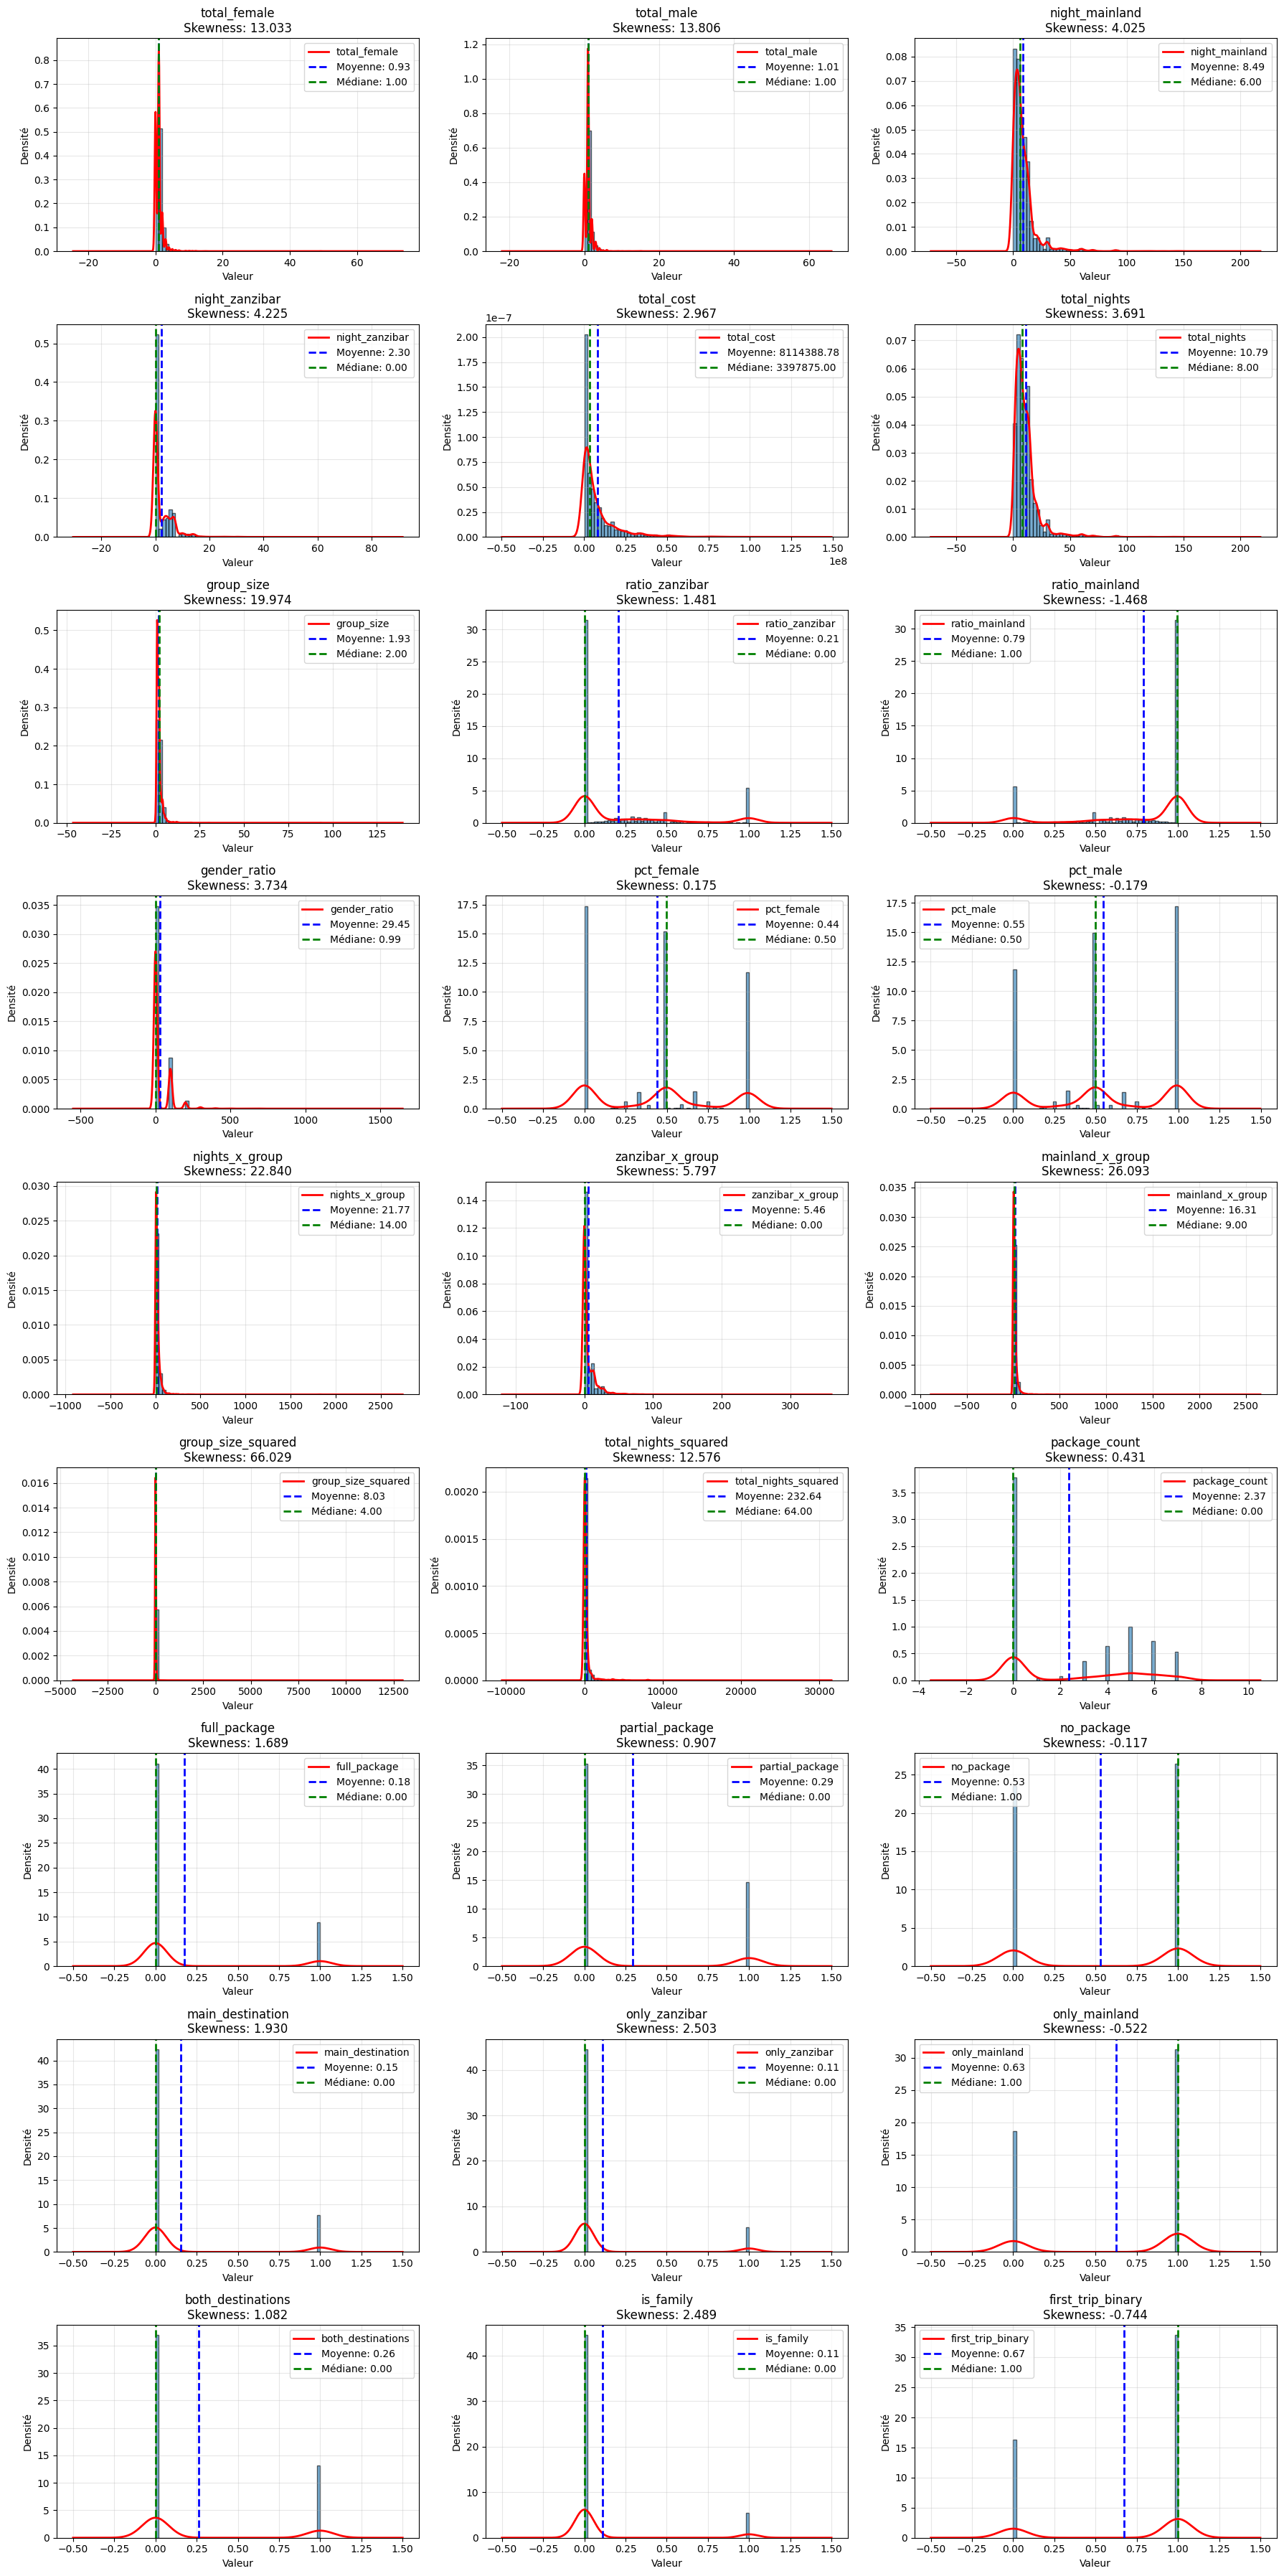


💡 RECOMMANDATIONS TRANSFORMATION :

⚠️ total_female
   Skewness : 13.033
   → TRANSFORMATION LOG recommandée

⚠️ total_male
   Skewness : 13.806
   → TRANSFORMATION LOG recommandée

⚠️ night_mainland
   Skewness : 4.025
   → TRANSFORMATION LOG recommandée

⚠️ night_zanzibar
   Skewness : 4.225
   → TRANSFORMATION LOG recommandée

⚠️ total_cost
   Skewness : 2.967
   → TRANSFORMATION LOG recommandée

⚠️ total_nights
   Skewness : 3.691
   → TRANSFORMATION LOG recommandée

⚠️ group_size
   Skewness : 19.974
   → TRANSFORMATION LOG recommandée

⚠️ ratio_zanzibar
   Skewness : 1.481
   → TRANSFORMATION LOG recommandée

⚠️ ratio_mainland
   Skewness : -1.468
   → TRANSFORMATION LOG recommandée

⚠️ gender_ratio
   Skewness : 3.734
   → TRANSFORMATION LOG recommandée

⚠️ nights_x_group
   Skewness : 22.840
   → TRANSFORMATION LOG recommandée

⚠️ zanzibar_x_group
   Skewness : 5.797
   → TRANSFORMATION LOG recommandée

⚠️ mainland_x_group
   Skewness : 26.093
   → TRANSFORMATION LOG recommand

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

def analyze_numerical_distribution(df):
    """
    Analyse complète de la distribution des variables numériques
    """
    # Sélectionner colonnes numériques
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    
    print("="*80)
    print("📊 ANALYSE DISTRIBUTION VARIABLES NUMÉRIQUES")
    print("="*80)
    
    # Tableau récapitulatif
    distribution_summary = []
    
    for col in num_cols:
        skewness = skew(df[col].dropna())
        
        summary = {
            'Variable': col,
            'Moyenne': df[col].mean(),
            'Médiane': df[col].median(),
            'Std': df[col].std(),
            'Min': df[col].min(),
            'Max': df[col].max(),
            'Skewness': skewness,
            'Interprétation': ''
        }
        
        # Interprétation skewness
        if abs(skewness) < 0.5:
            summary['Interprétation'] = '✅ Symétrique'
        elif abs(skewness) < 1:
            summary['Interprétation'] = '🟡 Modérément asymétrique'
        else:
            summary['Interprétation'] = '⚠️ Fortement asymétrique'
        
        distribution_summary.append(summary)
    
    # Afficher tableau
    df_summary = pd.DataFrame(distribution_summary)
    print("\n" + df_summary.to_string(index=False))
    
    # Visualisations
    n_cols_plot = len(num_cols)
    n_rows = (n_cols_plot + 2) // 3  # 3 colonnes par ligne
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4))
    axes = axes.flatten() if n_cols_plot > 1 else [axes]
    
    for idx, col in enumerate(num_cols):
        # Histogramme + KDE
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.6, density=True)
        df[col].dropna().plot(kind='kde', ax=axes[idx], color='red', linewidth=2)
        axes[idx].axvline(df[col].mean(), color='blue', linestyle='--', linewidth=2, label=f'Moyenne: {df[col].mean():.2f}')
        axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Médiane: {df[col].median():.2f}')
        axes[idx].set_title(f'{col}\nSkewness: {skew(df[col].dropna()):.3f}')
        axes[idx].set_xlabel('Valeur')
        axes[idx].set_ylabel('Densité')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)
    
    # Masquer axes vides
    for idx in range(len(num_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Recommandations
    print("\n" + "="*80)
    print("💡 RECOMMANDATIONS TRANSFORMATION :")
    print("="*80)
    
    for summary in distribution_summary:
        if abs(summary['Skewness']) > 1:
            print(f"\n⚠️ {summary['Variable']}")
            print(f"   Skewness : {summary['Skewness']:.3f}")
            print(f"   → TRANSFORMATION LOG recommandée")
        elif abs(summary['Skewness']) > 0.5:
            print(f"\n🟡 {summary['Variable']}")
            print(f"   Skewness : {summary['Skewness']:.3f}")
            print(f"   → Tester avec et sans transformation")
    
    return df_summary

# UTILISATION
distribution_analysis = analyze_numerical_distribution(num_data)




 Appliquer RobustScaler
scaler = RobustScaler()
num_data_scaled = scaler.fit_transform(num_data)

 Conserver les noms de colonnes si besoin
num_data_scaled = pd.DataFrame(
    num_data_scaled, 
    columns=num_data.columns,
    index=num_data.index
)

In [24]:
num_data

,total_female,total_male,night_mainland,night_zanzibar,total_cost,total_nights,group_size,ratio_zanzibar,ratio_mainland,gender_ratio,...,package_count,full_package,partial_package,no_package,main_destination,only_zanzibar,only_mainland,both_destinations,is_family,first_trip_binary
0,1.0,1.0,13.0,0.0,674602.5,13.0,2.0,0.000000,0.999231,0.990099,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,14.0,7.0,3214906.5,21.0,1.0,0.333175,0.666349,100.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.0,1.0,1.0,31.0,3315000.0,32.0,1.0,0.968447,0.031240,0.000000,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,1.0,11.0,0.0,7790250.0,11.0,2.0,0.000000,0.999092,0.990099,...,5.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,7.0,4.0,1657500.0,11.0,1.0,0.363306,0.635786,100.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,0.0,1.0,2.0,0.0,3315000.0,2.0,1.0,0.000000,0.995025,0.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4805,1.0,1.0,11.0,0.0,10690875.0,11.0,2.0,0.000000,0.999092,0.990099,...,7.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4806,1.0,0.0,3.0,7.0,2246636.7,10.0,1.0,0.699301,0.299700,100.000000,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
4807,1.0,1.0,5.0,0.0,1160250.0,5.0,2.0,0.000000,0.998004,0.990099,...,3.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [25]:
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ========================================
# FONCTION OBJECTIVE CORRIGÉE
# ========================================

def objective_rf_deep(trial):
    """
    Tuning Random Forest avec Cross-Validation
    MAE calculé en FCFA après double inverse (Scaler + Log)
    """
    # 1. Hyperparamètres suggérés
    bootstrap_val = trial.suggest_categorical('bootstrap', [True, False])
    
    if bootstrap_val:
        max_samples_val = trial.suggest_float('max_samples', 0.7, 1.0)
    else:
        max_samples_val = None
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600, step=50),
        'max_depth': trial.suggest_categorical('max_depth', [10, 20, 30, None]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.7]),
        # On reste sur squared_error pour la stabilité, Optuna jugera sur la MAE
        'criterion': 'squared_error', 
        'bootstrap': bootstrap_val,
        'random_state': 42,
        'n_jobs': -1
    }
    
    if max_samples_val is not None:
        params['max_samples'] = max_samples_val
    
    # 2. Cross-Validation (sur X_train_scaled et y_train_scaled)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae_scores = []
    
    # On utilise les données que tu as splitées et scalées juste avant
    # X_train_scaled et y_train_scaled (ou y_train si tu n'as pas scalé y)
    
    for train_idx, val_idx in kf.split(X_train_scaled):
        # Split des folds
        X_tr, X_vl = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_vl = y_train_scaled[train_idx], y_train_scaled[val_idx]
        
        # Entraînement sur les données transformées
        model = RandomForestRegressor(**params)
        model.fit(X_tr, y_tr)
        
        # Prédiction (en échelle transformée)
        y_pred = model.predict(X_vl)
        
        # ========================================
        # DOUBLE INVERSE TRANSFORM (C'est ici que se joue ta MAE)
        # ========================================
        # 1. On enlève le RobustScaler
        y_vl_inv = scaler_y.inverse_transform(y_vl.reshape(-1, 1)).flatten()
        y_pred_inv = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        
        # 2. On enlève le Log (retour aux FCFA)
        y_vl_real = np.expm1(y_vl_inv)
        y_pred_real = np.expm1(y_pred_inv)
        
        # 3. Calcul de la MAE sur les vrais montants
        mae = mean_absolute_error(y_vl_real, y_pred_real)
        mae_scores.append(mae)
    
    return np.mean(mae_scores)

# ========================================
# LANCEMENT DE L'OPTIMISATION
# ========================================

print("🌲 TUNING RANDOM FOREST : OPTIMISATION DE LA MAE EN FCFA...")
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf_deep, n_trials=5) # Commencer par 50 pour tester la vitesse

# ========================================
# ÉVALUATION FINALE (MONDE RÉEL)
# ========================================

print("\n🏆 MEILLEUR SCORE CV : {:,.0f} FCFA".format(study_rf.best_value))

# Entraînement final avec les meilleurs paramètres
best_params = study_rf.best_params
best_params['criterion'] = 'squared_error' # Assurer le critère stable
best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train_scaled, y_train_scaled)

# Prédiction sur le set de validation externe
y_val_pred_scaled = best_rf.predict(X_val_scaled)

# Inverse pour le rapport final
y_val_real = np.expm1(scaler_y.inverse_transform(y_val_scaled.reshape(-1, 1)).flatten())
y_val_pred_real = np.expm1(scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten())

mae_final = mean_absolute_error(y_val_real, y_val_pred_real)
print(f"📊 MAE FINALE SUR VAL SET : {mae_final:,.0f} FCFA")

[I 2026-02-05 22:43:44,200] A new study created in memory with name: no-name-c0a62397-1a43-44a2-93d9-cceff1ad6164


🌲 TUNING RANDOM FOREST : OPTIMISATION DE LA MAE EN FCFA...


[I 2026-02-05 22:43:58,283] Trial 0 finished with value: 4848567.6472186735 and parameters: {'bootstrap': False, 'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 4848567.6472186735.
[I 2026-02-05 22:44:21,812] Trial 1 finished with value: 4872358.395615315 and parameters: {'bootstrap': True, 'max_samples': 0.9561418911532005, 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 0.7}. Best is trial 0 with value: 4848567.6472186735.
[I 2026-02-05 22:45:21,814] Trial 2 finished with value: 4859775.922827037 and parameters: {'bootstrap': True, 'max_samples': 0.9917019710258066, 'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.7}. Best is trial 0 with value: 4848567.6472186735.
[I 2026-02-05 22:46:07,404] Trial 3 finished with value: 5009977.190879771 and parameters: {'bootstrap': False, 'n_estimators


🏆 MEILLEUR SCORE CV : 4,848,568 FCFA
📊 MAE FINALE SUR VAL SET : 5,170,740 FCFA


In [26]:
import pandas as pd
import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ========================================
# FONCTION OBJECTIVE XGBOOST
# ========================================

def objective_xgb(trial):
    """
    Tuning XGBoost avec Cross-Validation
    MAE calculé en FCFA après double inverse (Scaler + Log)
    """
    # 1. Hyperparamètres spécifiques à XGBoost
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 100, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 100, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'tree_method': 'hist', # Accélère l'entraînement
        'random_state': 42,
        'n_jobs': -1
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae_scores = []
    
    for train_idx, val_idx in kf.split(X_train_scaled):
        X_tr, X_vl = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_vl = y_train_scaled[train_idx], y_train_scaled[val_idx]
        
        # Modèle XGBoost
        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        
        # Prédiction
        y_pred = model.predict(X_vl)
        
        # DOUBLE INVERSE TRANSFORM (Scaler -> Log -> FCFA)
        y_vl_inv = scaler_y.inverse_transform(y_vl.reshape(-1, 1)).flatten()
        y_pred_inv = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        
        y_vl_real = np.expm1(y_vl_inv)
        y_pred_real = np.expm1(y_pred_inv)
        
        mae = mean_absolute_error(y_vl_real, y_pred_real)
        mae_scores.append(mae)
    
    return np.mean(mae_scores)

# ========================================
# LANCEMENT DE L'OPTIMISATION
# ========================================

print("🚀 TUNING XGBOOST : OPTIMISATION DE LA MAE EN FCFA...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=5, show_progress_bar=True)

# ========================================
# ÉVALUATION FINALE
# ========================================

print("\n🏆 MEILLEUR SCORE CV XGBOOST : {:,.0f} FCFA".format(study_xgb.best_value))

# Entraînement final avec les meilleurs paramètres
best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)
best_xgb.fit(X_train_scaled, y_train_scaled)

# Prédiction sur set de validation externe
y_val_pred_scaled = best_xgb.predict(X_val_scaled)

# Inversion finale
y_val_real = np.expm1(scaler_y.inverse_transform(y_val_scaled.reshape(-1, 1)).flatten())
y_val_pred_real = np.expm1(scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten())

mae_final = mean_absolute_error(y_val_real, y_val_pred_real)
print(f"📊 MAE FINALE XGBOOST SUR VAL SET : {mae_final:,.0f} FCFA")

[I 2026-02-05 22:46:26,451] A new study created in memory with name: no-name-85ac1f53-5d07-4398-82a3-08314728a64e


🚀 TUNING XGBOOST : OPTIMISATION DE LA MAE EN FCFA...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-05 22:48:15,890] Trial 0 finished with value: 5045607.84271661 and parameters: {'n_estimators': 1539, 'max_depth': 13, 'learning_rate': 0.011949050810188475, 'subsample': 0.8045305690457386, 'colsample_bytree': 0.7707967793977301, 'gamma': 7.898217301454115e-05, 'reg_alpha': 2.782321645502677e-06, 'reg_lambda': 1.1370777083822289e-05, 'min_child_weight': 6}. Best is trial 0 with value: 5045607.84271661.
[I 2026-02-05 22:49:53,722] Trial 1 finished with value: 5034275.5941423755 and parameters: {'n_estimators': 1289, 'max_depth': 14, 'learning_rate': 0.010813365603285292, 'subsample': 0.6809905867296744, 'colsample_bytree': 0.7781809656035776, 'gamma': 3.6295413861098485e-05, 'reg_alpha': 4.724692690921148e-06, 'reg_lambda': 0.011279894718478704, 'min_child_weight': 5}. Best is trial 1 with value: 5034275.5941423755.
[I 2026-02-05 22:50:03,866] Trial 2 finished with value: 4802645.942160318 and parameters: {'n_estimators': 1120, 'max_depth': 8, 'learning_rate': 0.046866503562

In [27]:
# Meilleurs paramètres trouvés
params_rf = {'bootstrap': False, 'n_estimators': 450, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
#params_xgb = {'n_estimators': 925, 'max_depth': 10, 'learning_rate': 0.0207, 'subsample': 0.8541, 'colsample_bytree': 0.8043, 'gamma': 0.1811, 'reg_alpha': 2.28, 'reg_lambda': 7.35e-08, 'min_child_weight': 4, 'random_state': 42}
params_xgb = {'n_estimators': 1075, 'max_depth': 6, 'learning_rate': 0.017043353119457556, 'subsample': 0.8439956680029058, 'colsample_bytree': 0.6422748126617244, 'gamma': 0.24777196146689354, 'reg_alpha': 4.79399245323195e-05, 'reg_lambda': 8.071942973197822e-07, 'min_child_weight': 3}

# Entraînement sur TOUT le set d'entraînement (X_train_scaled + X_val_scaled)
X_final_train = np.vstack([X_train_scaled, X_val_scaled])
y_final_train = np.concatenate([y_train_scaled, y_val_scaled])

model_rf = RandomForestRegressor(**params_rf).fit(X_final_train, y_final_train)
model_xgb = XGBRegressor(**params_xgb).fit(X_final_train, y_final_train)

In [28]:
# Chargement du test
test_raw = pd.read_csv('test.csv')
test_id = test_raw['ID'] # On garde les ID pour la soumission

# 1. Feature Engineering
test_df = create_features(test_raw)

# 2. Séparation Num / Cat
test_num = test_df[num_clean.drop('total_cost', axis=1).columns]
test_cat = test_df[cat_data.columns]

# 3. Encoding Catégoriel (Utiliser les objets déjà fittés sur le train !)
# One-Hot sur low_card
test_encoded_low = encoder.transform(test_cat[low_card])

# Frequency Encoding sur high_card (en utilisant les maps du train)
test_encoded_high = test_cat[high_card].copy()
for col in high_card:
    freq_map = cat_data[col].value_counts(normalize=True)
    test_encoded_high[col] = test_cat[col].map(freq_map).fillna(0) # fillna si nouvelle valeur

test_cat_final = pd.concat([
    pd.DataFrame(test_encoded_low, columns=encoder.get_feature_names_out()),
    test_encoded_high.reset_index(drop=True)
], axis=1)

# 4. Log Transformation sur le numérique
test_num_log = np.log1p(test_num)

# 5. Fusion et Scaling
X_test_transformed = pd.concat([test_num_log.reset_index(drop=True), test_cat_final], axis=1)
X_test_scaled = scaler_x.transform(X_test_transformed)

🔧 FEATURE ENGINEERING EN COURS...
1️⃣ Features numériques...
2️⃣ Features catégorielles combinées...
✅ Features créées : 46 colonnes


In [29]:
# Prédictions (en mode Scaled Log)
pred_rf = model_rf.predict(X_test_scaled)
pred_xgb = model_xgb.predict(X_test_scaled)

# Blending (70% XGBoost / 30% RF)
final_pred_scaled = (0.7 * pred_xgb) + (0.3 * pred_rf)
#final_pred_scaled=pred_xgb


# --- DOUBLE INVERSION ---
# 1. Retour au Log
final_pred_log = scaler_y.inverse_transform(final_pred_scaled.reshape(-1, 1)).flatten()

# 2. Retour au FCFA
final_pred_fcfa = np.expm1(final_pred_log)

# Création du fichier final
submission = pd.DataFrame({
    'ID': test_id,
    'total_cost': final_pred_fcfa
})

submission.to_csv('submission_champion.csv', index=False)
print("🚀 Fichier prêt pour Zindi !")

🚀 Fichier prêt pour Zindi !


In [30]:
import pickle

# 1. Sauvegarde du modèle
with open('model.pkl', 'wb') as f_model:
    pickle.dump(model_xgb, f_model)
print("✅ Modèle sauvegardé dans model.pkl")

# 2. Sauvegarde du scaler
with open('scaler_y.pkl', 'wb') as f_scaler:
    pickle.dump(scaler_y, f_scaler)
print("✅ Scaler sauvegardé dans scaler.pkl")

with open('scaler_x.pkl', 'wb') as f_scaler:
    pickle.dump(scaler_x, f_scaler)
print("✅ Scaler sauvegardé dans scaler.pkl")



# 3. Sauvegarde de l'encoder
with open('encoder.pkl', 'wb') as f_encoder:
    pickle.dump(encoder, f_encoder)
print("✅ Encoder sauvegardé dans encoder.pkl")

✅ Modèle sauvegardé dans model.pkl
✅ Scaler sauvegardé dans scaler.pkl
✅ Scaler sauvegardé dans scaler.pkl
✅ Encoder sauvegardé dans encoder.pkl


In [31]:
import pickle
import numpy as np
import pandas as pd
from fastapi import FastAPI

app = FastAPI(title="Tourisme")

# --- CHARGEMENT DES OBJETS (Une seule fois au démarrage) ---
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler_x = pickle.load(f)
with open('encoder.pkl', 'rb') as f:
    encoder = pickle.load(f)
# Tu devrais aussi avoir un pickle pour tes fréquences !
# with open('freq_maps.pkl', 'rb') as f:
#     freq_maps = pickle.load(f)

# Liste des colonnes attendues (à remplir selon ton X_train)
COLS_RAW = [
    'country', 'age_group', 'travel_with', 'total_female', 'total_male', 
    'purpose', 'main_activity', 'info_source', 'tour_arrangement', 
    'package_transport_int', 'package_accomodation', 'package_food', 
    'package_transport_tz', 'package_sightseeing', 'package_guided_tour', 
    'package_insurance', 'night_mainland', 'night_zanzibar', 
    'payment_mode', 'first_trip_tz', 'most_impressing'
]
@app.post("/prediction")
def prediction(input_data: dict):
    # 0. Chargement en DataFrame
    test_raw = pd.DataFrame([input_data])
    
    # 1. Feature Engineering (Assure-toi que cette fonction est définie avant)
    test_df = create_features(test_raw)

    
    # 2. Séparation et Traitement
    # Note: Assure-toi que les colonnes existent avant de drop
    liste_colonnes_numeriques = [
    'total_female', 
    'total_male', 
    'night_mainland', 
    'night_zanzibar'
        ]

    liste_colonnes_categoriques = [
    'country', 
    'age_group', 
    'travel_with', 
    'purpose', 
    'main_activity', 
    'info_source', 
    'tour_arrangement', 
    'package_transport_int', 
    'package_accomodation', 
    'package_food', 
    'package_transport_tz', 
    'package_sightseeing', 
    'package_guided_tour', 
    'package_insurance', 
    'payment_mode', 
    'first_trip_tz', 
    'most_impressing'
    ]
    test_num = test_df[liste_colonnes_numeriques] 
    test_cat = test_df[liste_colonnes_categoriques]

    low_card = [col for col in test_cat.columns if cat_data[col].nunique() <= 10]
    high_card = [col for col in test_cat.columns if cat_data[col].nunique() > 10]

    # 3. Encoding (One-Hot)
    test_encoded_low = encoder.transform(test_cat[low_card])
    
    # 4. Frequency Encoding (Utilisation des maps sauvegardées)
    test_encoded_high = test_cat[high_card].copy()
    for col in high_card:
        # On utilise .get() pour éviter une erreur si la valeur est nouvelle
        test_encoded_high[col] = test_cat[col].map(freq_maps[col]).fillna(0)

    # 5. Assemblage
    test_cat_final = pd.concat([
        pd.DataFrame(test_encoded_low, columns=encoder.get_feature_names_out()),
        test_encoded_high.reset_index(drop=True)
    ], axis=1)

    # 6. Log Transformation & Scaling
    test_num_log = np.log1p(test_num)
    X_test_transformed = pd.concat([test_num_log.reset_index(drop=True), test_cat_final], axis=1)
    
    # TRÈS IMPORTANT : Réorganiser les colonnes pour matcher le X_train
    X_test_transformed = X_test_transformed[model.feature_names_in_]
    
    X_test_scaled = scaler_x.transform(X_test_transformed)

    # 7. Prédiction
    res_log = model.predict(X_test_scaled)
    
    # Si ton modèle a été entraîné sur le log du prix, n'oublie pas l'inverse !
    res_final = np.expm1(res_log) 
    
    return {"prediction": float(res_final[0])}